<a href="https://colab.research.google.com/github/owlleeve/Tugas-Besar-ASA/blob/main/SARS_CoV_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h2>Tugas Besar ASA 2026</h2>

<table>
  <tr><td><b>Nama</b></td><td>:  Olivia Oktaviani</td></tr>
  <tr><td><b>NIM</b></td><td>:  24060124120050</td></tr>
  <tr><td><b>Departemen</b></td><td>:  Informatika</td></tr>
  <tr><td><b>Universitas</b></td><td>:  Universitas Diponegoro</td></tr>
  <tr><td><b>Mata Kuliah</b></td><td>:  Analisis dan Strategi Algoritma</td></tr>
  <tr><td><b>Dosen Pengampu</b></td><td>:  Sandy Kurniawan, S.Kom., M.Kom</td></tr>
  <tr><td><b>Judul Tugas</b></td><td>:  Analisis Perbandingan Dynamic Programming, Brute Force, dan Beam Search pada Penyelarasan Sekuens DNA SARS-CoV-2</td></tr>
</table>

In [1]:
# 1. Import Library

# biopython  : baca file FASTA dari NCBI
# numpy      : operasi matriks untuk Needleman-Wunsch
# pandas     : menyimpan dan menampilkan hasil eksperimen
# matplotlib : visualisasi grafik perbandingan
# seaborn    : heatmap matriks skor DP
# tracemalloc: mengukur penggunaan memori saat eksperimen
# time       : mengukur waktu eksekusi
# itertools  : membangkitkan kombinasi gap untuk brute force
import subprocess
subprocess.run(['pip', 'install', 'biopython', 'numpy', 'pandas',
                'matplotlib', 'seaborn'], capture_output=True)
import os
import time
import tracemalloc
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import Entrez, SeqIO

os.makedirs('data', exist_ok=True)
os.makedirs('results', exist_ok=True)

print("Library berhasil diimport")
print("Folder data/ dan results/ sudah siap")

Library berhasil diimport
Folder data/ dan results/ sudah siap


In [2]:
# 2. Dataset dari NCBI

from google.colab import drive
drive.mount('/content/drive')

import shutil
import os

os.makedirs('/content/drive/MyDrive/sars_cov2/data', exist_ok=True)
os.makedirs('data', exist_ok=True)

file_list = {
    'wuhan'       : '/content/drive/MyDrive/sars_cov2/data/wuhan.fasta',
    'delta'       : '/content/drive/MyDrive/sars_cov2/data/delta.fasta',
    'omicron_ba1' : '/content/drive/MyDrive/sars_cov2/data/omicron_ba1.fasta',
}

for nama, path_drive in file_list.items():
    if os.path.exists(path_drive):
        shutil.copy(path_drive, f'data/{nama}.fasta')
        print(f"{nama}.fasta dimuat dari Drive")
    else:
        print(f"{nama}.fasta belum ada di Drive")
        print(f"Upload dulu ke: /MyDrive/sars_cov2/data/")

Mounted at /content/drive
wuhan.fasta dimuat dari Drive
delta.fasta dimuat dari Drive
omicron_ba1.fasta dimuat dari Drive


In [3]:
# 3. Load dan Preview Sekuens
def baca_fasta(filepath):
    record = SeqIO.read(filepath, "fasta")
    return str(record.seq).upper()
seq_wuhan   = baca_fasta("data/wuhan.fasta")
seq_delta   = baca_fasta("data/delta.fasta")
seq_omicron = baca_fasta("data/omicron_ba1.fasta")
print("Sekuens yang berhasil dimuat:")
print(f"  Wuhan        : {len(seq_wuhan):,} bp  | 5 basa awal: {seq_wuhan[:5]}")
print(f"  Delta        : {len(seq_delta):,} bp  | 5 basa awal: {seq_delta[:5]}")
print(f"  Omicron BA.1 : {len(seq_omicron):,} bp  | 5 basa awal: {seq_omicron[:5]}")

Sekuens yang berhasil dimuat:
  Wuhan        : 29,903 bp  | 5 basa awal: ATTAA
  Delta        : 29,855 bp  | 5 basa awal: TAAAG
  Omicron BA.1 : 29,684 bp  | 5 basa awal: AGATC


In [4]:
# 4. Ekstrak Spike Protein

# posisi spike protein berdasarkan anotasi NC_045512.2
MULAI = 21562
AKHIR = 25384
spike_wuhan   = seq_wuhan[MULAI:AKHIR]
spike_delta   = seq_delta[MULAI:AKHIR]
spike_omicron = seq_omicron[MULAI:AKHIR]
print(f"Spike protein diekstrak dari posisi {MULAI+1} sampai {AKHIR}")
print(f"  Wuhan   : {len(spike_wuhan)} bp")
print(f"  Delta   : {len(spike_delta)} bp")
print(f"  Omicron : {len(spike_omicron)} bp")

# hitung perbedaan kasar sebelum alignment
def hitung_beda(s1, s2):
    panjang = min(len(s1), len(s2))
    return sum(1 for i in range(panjang) if s1[i] != s2[i])
print("\nperbedaan posisi tanpa alignment (gambaran awal):")
print(f"  Wuhan vs Delta   : {hitung_beda(spike_wuhan, spike_delta)} posisi")
print(f"  Wuhan vs Omicron : {hitung_beda(spike_wuhan, spike_omicron)} posisi")
print(f"  Delta vs Omicron : {hitung_beda(spike_delta, spike_omicron)} posisi")
print("catatan: angka ini belum mempertimbangkan gap, jadi belum akurat")

Spike protein diekstrak dari posisi 21563 sampai 25384
  Wuhan   : 3822 bp
  Delta   : 3822 bp
  Omicron : 3822 bp

perbedaan posisi tanpa alignment (gambaran awal):
  Wuhan vs Delta   : 2851 posisi
  Wuhan vs Omicron : 2778 posisi
  Delta vs Omicron : 2818 posisi
catatan: angka ini belum mempertimbangkan gap, jadi belum akurat


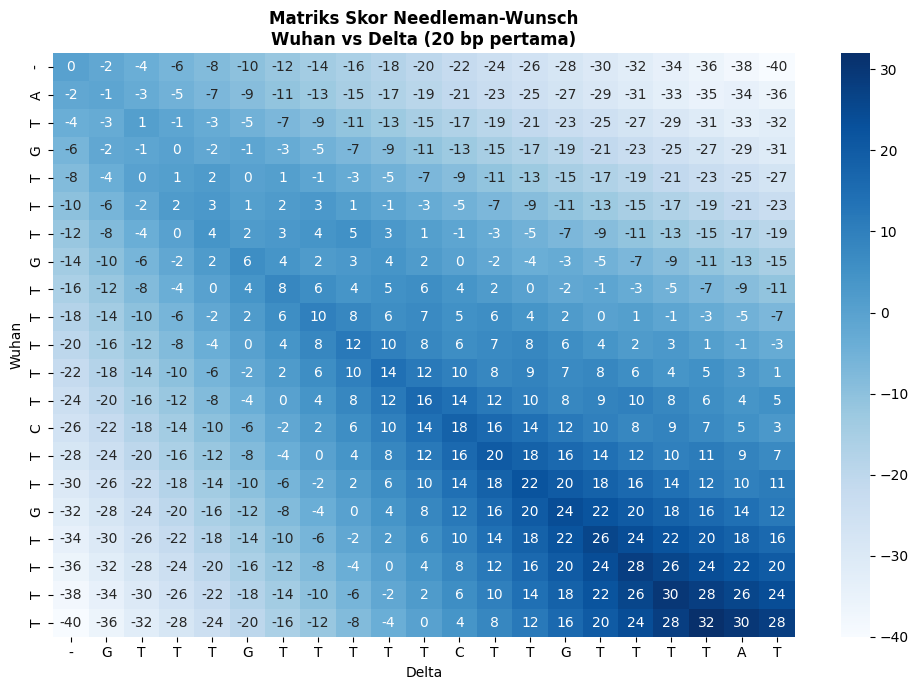

uji coba Needleman-Wunsch:
  seq1   : ATGCTA
  seq2   : ATCTA
  hasil1 : ATGCTA
  hasil2 : AT-CTA
  skor   : 8


In [5]:
# 5. Dynamic Programming (Needleman-Wunsch)

# kompleksitas waktu: O(m x n)
# kompleksitas memori: O(m x n)
def needleman_wunsch(seq1, seq2, match=2, mismatch=-1, gap=-2):
    m = len(seq1)
    n = len(seq2)
    matriks = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1):
        matriks[i][0] = i * gap
    for j in range(n + 1):
        matriks[0][j] = j * gap
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if seq1[i-1] == seq2[j-1]:
                skor_diagonal = matriks[i-1][j-1] + match
            else:
                skor_diagonal = matriks[i-1][j-1] + mismatch
            skor_atas  = matriks[i-1][j] + gap
            skor_kiri  = matriks[i][j-1] + gap
            matriks[i][j] = max(skor_diagonal, skor_atas, skor_kiri)
    hasil1 = ""
    hasil2 = ""
    i, j = m, n
    while i > 0 or j > 0:
        if i > 0 and j > 0:
            if seq1[i-1] == seq2[j-1]:
                skor_diag = matriks[i-1][j-1] + match
            else:
                skor_diag = matriks[i-1][j-1] + mismatch
            if matriks[i][j] == skor_diag:
                hasil1 = seq1[i-1] + hasil1
                hasil2 = seq2[j-1] + hasil2
                i -= 1
                j -= 1
            elif matriks[i][j] == matriks[i-1][j] + gap:
                hasil1 = seq1[i-1] + hasil1
                hasil2 = "-" + hasil2
                i -= 1
            else:
                hasil1 = "-" + hasil1
                hasil2 = seq2[j-1] + hasil2
                j -= 1
        elif i > 0:
            hasil1 = seq1[i-1] + hasil1
            hasil2 = "-" + hasil2
            i -= 1
        else:
            hasil1 = "-" + hasil1
            hasil2 = seq2[j-1] + hasil2
            j -= 1
    return matriks[m][n], hasil1, hasil2

def visualisasi_matriks(seq1, seq2, match=2, mismatch=-1, gap=-2):
    m = len(seq1)
    n = len(seq2)
    matriks = np.zeros((m + 1, n + 1), dtype=np.int32)
    matriks[:, 0] = np.arange(m + 1) * gap
    matriks[0, :] = np.arange(n + 1) * gap
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if seq1[i-1] == seq2[j-1]:
                skor_diag = matriks[i-1][j-1] + match
            else:
                skor_diag = matriks[i-1][j-1] + mismatch
            matriks[i][j] = max(skor_diag,
                                matriks[i-1][j] + gap,
                                matriks[i][j-1] + gap)
    label_baris = ["-"] + list(seq1)
    label_kolom = ["-"] + list(seq2)
    plt.figure(figsize=(10, 7))
    sns.heatmap(matriks, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_kolom, yticklabels=label_baris)
    plt.title("Matriks Skor Needleman-Wunsch\nWuhan vs Delta (20 bp pertama)",
              fontsize=12, fontweight="bold")
    plt.xlabel("Delta")
    plt.ylabel("Wuhan")
    plt.tight_layout()
    plt.savefig("results/heatmap_matriks_dp.png", dpi=150)
    plt.show()

visualisasi_matriks(spike_wuhan[:20], spike_delta[:20])

skor, al1, al2 = needleman_wunsch("ATGCTA", "ATCTA")
print("uji coba Needleman-Wunsch:")
print(f"  seq1   : ATGCTA")
print(f"  seq2   : ATCTA")
print(f"  hasil1 : {al1}")
print(f"  hasil2 : {al2}")
print(f"  skor   : {skor}")

In [6]:
# 6. Brute Force

# Kompleksitas: eksponensial, dibatasi maksimal 15 karakter

def hitung_skor(al1, al2, match=2, mismatch=-1, gap=-2):
    skor = 0
    for a, b in zip(al1, al2):
        if a == "-" or b == "-":
            skor += gap
        elif a == b:
            skor += match
        else:
            skor += mismatch
    return skor

def sisipkan_gap(sekuens, max_gap=3):
    hasil = set()
    n = len(sekuens)
    for jumlah_gap in range(min(max_gap, n) + 1):
        for posisi in itertools.combinations(range(n + jumlah_gap), jumlah_gap):
            karakter = list(sekuens)
            baru = []
            idx = 0
            for i in range(n + jumlah_gap):
                if i in posisi:
                    baru.append("-")
                else:
                    if idx < len(karakter):
                        baru.append(karakter[idx])
                        idx += 1
            hasil.add("".join(baru))
    return hasil

def brute_force(seq1, seq2, match=2, mismatch=-1, gap=-2):
    BATAS = 15
    if len(seq1) > BATAS or len(seq2) > BATAS:
        return None, None, None
    semua_al1 = sisipkan_gap(seq1, max_gap=3)
    semua_al2 = sisipkan_gap(seq2, max_gap=3)
    skor_terbaik = float("-inf")
    al1_terbaik  = ""
    al2_terbaik  = ""
    for al1 in semua_al1:
        for al2 in semua_al2:
            if len(al1) != len(al2):
                continue
            s = hitung_skor(al1, al2, match, mismatch, gap)
            if s > skor_terbaik:
                skor_terbaik = s
                al1_terbaik  = al1
                al2_terbaik  = al2
    return skor_terbaik, al1_terbaik, al2_terbaik

def visualisasi_brute_force(seq1, seq2, match=2, mismatch=-1, gap=-2, tampil_max=10):
    print(f"Brute Force: seq1: {seq1}  |  seq2: {seq2}")
    print("cara kerja: semua kemungkinan sisipan gap dibangkitkan,")
    print("lalu setiap pasangan dihitung skornya dan dipilih yang terbaik.")
    print()
    semua_al1 = sisipkan_gap(seq1, max_gap=3)
    semua_al2 = sisipkan_gap(seq2, max_gap=3)
    kandidat = []
    for al1 in semua_al1:
        for al2 in semua_al2:
            if len(al1) != len(al2):
                continue
            s = hitung_skor(al1, al2, match, mismatch, gap)
            kandidat.append((s, al1, al2))
    kandidat.sort(key=lambda x: -x[0])
    print(f"total kombinasi valid: {len(kandidat)}")
    print(f"menampilkan {min(tampil_max, len(kandidat))} kombinasi dengan skor tertinggi:")
    print()
    print(f"  {'No':<5} {'Seq1':<18} {'Seq2':<18} {'Skor':>6}  {'Keterangan'}")
    print("  " + "-" * 55)
    for i, (s, a1, a2) in enumerate(kandidat[:tampil_max], 1):
        ket = "<-- dipilih sebagai hasil akhir" if i == 1 else ""
        print(f"  {i:<5} {a1:<18} {a2:<18} {s:>6}  {ket}")
    print()
    print(f"  hasil terbaik : {kandidat[0][1]}  /  {kandidat[0][2]}")
    print(f"  skor          : {kandidat[0][0]}")

SEQ1 = "ATGCTA"
SEQ2 = "ATCTA"
visualisasi_brute_force(SEQ1, SEQ2)
print()
skor_bf, al1_bf, al2_bf = brute_force(SEQ1, SEQ2)
skor_dp, _, _           = needleman_wunsch(SEQ1, SEQ2)
print("verifikasi brute force vs DP:")
print(f"  hasil BF : {al1_bf}  /  {al2_bf}  (skor: {skor_bf})")
print(f"  skor DP  : {skor_dp}")
if skor_bf == skor_dp:
    print("  skor sama, berarti brute force valid sebagai pembanding")
else:
    print("  skor berbeda, kemungkinan karena batasan max_gap=3")
print()
print("catatan: brute force hanya bisa jalan di sekuens <= 15 bp")
print("         karena jumlah kombinasi tumbuh eksponensial")


Brute Force: seq1: ATGCTA  |  seq2: ATCTA
cara kerja: semua kemungkinan sisipan gap dibangkitkan,
lalu setiap pasangan dihitung skornya dan dipilih yang terbaik.

total kombinasi valid: 1721
menampilkan 10 kombinasi dengan skor tertinggi:

  No    Seq1               Seq2                 Skor  Keterangan
  -------------------------------------------------------
  1     ATGCTA             AT-CTA                  8  <-- dipilih sebagai hasil akhir
  2     ATGCT-A            AT-CT-A                 6  
  3     ATGC-TA            AT-C-TA                 6  
  4     AT-GCTA            AT--CTA                 6  
  5     ATG-CTA            AT--CTA                 6  
  6     ATGCTA-            AT-CTA-                 6  
  7     -ATGCTA            -AT-CTA                 6  
  8     A-TGCTA            A-T-CTA                 6  
  9     ATGCTA             A-TCTA                  5  
  10    ATGCTA             ATC-TA                  5  

  hasil terbaik : ATGCTA  /  AT-CTA
  skor          : 8

In [7]:
# 7. Beam Search

# Kompleksitas: O((m+n) x beam_width)
def beam_search(seq1, seq2, beam_width=5, match=2, mismatch=-1, gap=-2):
    m = len(seq1)
    n = len(seq2)
    beam = [(0, 0, 0, "", "")]
    while True:
        semua_selesai = all(i == m and j == n for _, i, j, _, _ in beam)
        if semua_selesai:
            break
        kandidat = []
        for skor, i, j, h1, h2 in beam:
            if i == m and j == n:
                kandidat.append((skor, i, j, h1, h2))
                continue
            if i < m and j < n:
                tambah = match if seq1[i] == seq2[j] else mismatch
                kandidat.append((skor + tambah, i+1, j+1, h1 + seq1[i], h2 + seq2[j]))
            if i < m:
                kandidat.append((skor + gap, i+1, j, h1 + seq1[i], h2 + "-"))
            if j < n:
                kandidat.append((skor + gap, i, j+1, h1 + "-", h2 + seq2[j]))
        kandidat.sort(key=lambda x: -x[0])
        sudah_ada = set()
        kandidat_unik = []
        for c in kandidat:
            kunci = (c[1], c[2])
            if kunci not in sudah_ada:
                sudah_ada.add(kunci)
                kandidat_unik.append(c)
        beam = kandidat_unik[:beam_width]
    terbaik = max(beam, key=lambda x: x[0])
    return terbaik[0], terbaik[3], terbaik[4]

def visualisasi_beam_search(seq1, seq2, beam_width=3, match=2, mismatch=-1, gap=-2):
    m = len(seq1)
    n = len(seq2)
    print(f"Beam Search: seq1 = {seq1}, seq2 = {seq2}, beam_width = {beam_width}")
    print(f"cara kerja: tiap langkah hanya simpan {beam_width} kandidat terbaik, sisanya dibuang")
    print()
    beam    = [(0, 0, 0, "", "")]
    iterasi = 0
    while True:
        semua_selesai = all(i == m and j == n for _, i, j, _, _ in beam)
        if semua_selesai:
            break
        kandidat = []
        for skor, i, j, h1, h2 in beam:
            if i == m and j == n:
                kandidat.append((skor, i, j, h1, h2))
                continue
            if i < m and j < n:
                tambah = match if seq1[i] == seq2[j] else mismatch
                kandidat.append((skor + tambah, i+1, j+1, h1 + seq1[i], h2 + seq2[j]))
            if i < m:
                kandidat.append((skor + gap, i+1, j, h1 + seq1[i], h2 + "-"))
            if j < n:
                kandidat.append((skor + gap, i, j+1, h1 + "-", h2 + seq2[j]))
        kandidat.sort(key=lambda x: -x[0])
        sudah_ada = set()
        kandidat_unik = []
        for c in kandidat:
            kunci = (c[1], c[2])
            if kunci not in sudah_ada:
                sudah_ada.add(kunci)
                kandidat_unik.append(c)
        iterasi += 1
        print(f"  iterasi {iterasi}: {len(kandidat_unik)} kandidat, simpan {min(beam_width, len(kandidat_unik))} terbaik")
        print(f"  {'status':<8} {'skor':>5}  {'seq1':<14} {'seq2':<14}")
        print("  " + "-" * 42)
        for idx, (s, i, j, h1, h2) in enumerate(kandidat_unik):
            status = "SIMPAN" if idx < beam_width else "BUANG"
            tampil1 = h1 if h1 else "(awal)"
            tampil2 = h2 if h2 else "(awal)"
            print(f"  {status:<8} {s:>5}  {tampil1:<14} {tampil2:<14}")
        beam = kandidat_unik[:beam_width]
        print()
    terbaik = max(beam, key=lambda x: x[0])
    print(f"  hasil akhir: {terbaik[3]}  /  {terbaik[4]}  (skor: {terbaik[0]})")

SEQ1 = "ATGCTA"
SEQ2 = "ATCTA"
visualisasi_beam_search(SEQ1, SEQ2, beam_width=3)
print()
print(f"pengaruh beam_width terhadap hasil (seq1 = {SEQ1}, seq2 = {SEQ2}):")
print()
print(f"  {'beam_width':<12} {'skor':>6}  {'seq1':<18} {'seq2'}")
print("  " + "-" * 50)
skor_dp, _, _ = needleman_wunsch(SEQ1, SEQ2)
for k in [3, 5, 10]:
    skor_bs, al1_bs, al2_bs = beam_search(SEQ1, SEQ2, beam_width=k)
    selisih = skor_bs - skor_dp
    ket = "(sama dengan DP)" if selisih == 0 else f"(selisih {selisih:+} dari DP)"
    print(f"  k={k:<10} {skor_bs:>6}  {al1_bs:<18} {al2_bs}  {ket}")
print()
print(f"  skor DP sebagai referensi: {skor_dp}")
print("semakin besar beam_width, hasilnya semakin dekat ke DP")

Beam Search: seq1 = ATGCTA, seq2 = ATCTA, beam_width = 3
cara kerja: tiap langkah hanya simpan 3 kandidat terbaik, sisanya dibuang

  iterasi 1: 3 kandidat, simpan 3 terbaik
  status    skor  seq1           seq2          
  ------------------------------------------
  SIMPAN       2  A              A             
  SIMPAN      -2  A              -             
  SIMPAN      -2  -              A             

  iterasi 2: 6 kandidat, simpan 3 terbaik
  status    skor  seq1           seq2          
  ------------------------------------------
  SIMPAN       4  AT             AT            
  SIMPAN       0  AT             A-            
  SIMPAN       0  A-             AT            
  BUANG       -4  AT             --            
  BUANG       -4  A-             -A            
  BUANG       -4  --             AT            

  iterasi 3: 6 kandidat, simpan 3 terbaik
  status    skor  seq1           seq2          
  ------------------------------------------
  SIMPAN       3  ATG        

In [8]:
# 8. Fungsi Eksperimen

def jalankan_eksperimen(seq1, seq2, nama_algo, panjang, beam_width=5):
    s1 = seq1[:panjang]
    s2 = seq2[:panjang]
    tracemalloc.start()
    waktu_mulai = time.perf_counter()
    if nama_algo == "Dynamic Programming":
        skor, _, _ = needleman_wunsch(s1, s2)
    elif nama_algo == "Brute Force":
        if panjang > 15:
            tracemalloc.stop()
            return {
                "Algoritma"     : nama_algo,
                "Panjang (bp)"  : panjang,
                "Skor"          : "-",
                "Waktu (detik)" : "-",
                "Memori (KB)"   : "-",
                "Keterangan"    : "Tidak dijalankan (> 15 bp)"
            }
        skor, _, _ = brute_force(s1, s2)
    else:
        skor, _, _ = beam_search(s1, s2, beam_width=beam_width)
    waktu_selesai = time.perf_counter()
    _, puncak_memori = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return {
        "Algoritma"     : nama_algo,
        "Panjang (bp)"  : panjang,
        "Skor"          : skor,
        "Waktu (detik)" : round(waktu_selesai - waktu_mulai, 6),
        "Memori (KB)"   : round(puncak_memori / 1024, 2),
        "Keterangan"    : "OK"
    }
print("fungsi eksperimen siap")

fungsi eksperimen siap


In [9]:
# 9. Jalankan Semua Eksperimen

# Variasi panjang sekuens yang diuji
panjang_uji = [10, 15, 100, 1000, 5000]

# Pasangan varian yang dibandingkan
pasangan = {
    "Wuhan vs Delta"   : (spike_wuhan, spike_delta),
    "Wuhan vs Omicron" : (spike_wuhan, spike_omicron),
    "Delta vs Omicron" : (spike_delta, spike_omicron),
}

# Algoritma dan beam width masing-masing
algoritma_list = [
    ("Dynamic Programming", 0),
    ("Brute Force",         0),
    ("Beam Search (k=3)",   3),
    ("Beam Search (k=5)",   5),
    ("Beam Search (k=10)", 10),
]
semua_hasil = []

for nama_pasangan, (s1, s2) in pasangan.items():
    print(f"\nPasangan: {nama_pasangan}")
    print("-" * 40)
    for panjang in panjang_uji:
        print(f"\n  [ {panjang} bp ]")
        for nama_algo, bw in algoritma_list:
            hasil = jalankan_eksperimen(s1, s2, nama_algo, panjang, bw)
            hasil["Pasangan"] = nama_pasangan
            semua_hasil.append(hasil)
            print(f"  {nama_algo:<25} | skor: {str(hasil['Skor']):<8} | "
                  f"waktu: {str(hasil['Waktu (detik)']):<12} | {hasil['Keterangan']}")
df_hasil = pd.DataFrame(semua_hasil)
print(f"\nselesai. total data: {len(df_hasil)} baris")


Pasangan: Wuhan vs Delta
----------------------------------------

  [ 10 bp ]
  Dynamic Programming       | skor: 8        | waktu: 0.000591     | OK
  Brute Force               | skor: 8        | waktu: 0.518705     | OK
  Beam Search (k=3)         | skor: 8        | waktu: 0.000583     | OK
  Beam Search (k=5)         | skor: 8        | waktu: 0.00084      | OK
  Beam Search (k=10)        | skor: 8        | waktu: 0.001344     | OK

  [ 15 bp ]
  Dynamic Programming       | skor: 18       | waktu: 0.001116     | OK
  Brute Force               | skor: 18       | waktu: 6.234668     | OK
  Beam Search (k=3)         | skor: 9        | waktu: 0.000909     | OK
  Beam Search (k=5)         | skor: 18       | waktu: 0.001305     | OK
  Beam Search (k=10)        | skor: 18       | waktu: 0.002284     | OK

  [ 100 bp ]
  Dynamic Programming       | skor: 185      | waktu: 0.049975     | OK
  Brute Force               | skor: -        | waktu: -            | Tidak dijalankan (> 15 bp)
  Bea

In [10]:
# 10. Tabel Hasil per Pasangan

# Tabel Hasil per Pasangan
for nama_pasangan in pasangan.keys():
    df_tampil = df_hasil[df_hasil["Pasangan"] == nama_pasangan].copy()
    df_tampil = df_tampil[["Algoritma", "Panjang (bp)", "Skor",
                            "Waktu (detik)", "Memori (KB)", "Keterangan"]]
    df_tampil = df_tampil.reset_index(drop=True)
    print()
    print(f"Hasil: {nama_pasangan}")
    print("-" * 40)
    display(df_tampil)
    print()


Hasil: Wuhan vs Delta
----------------------------------------


,Algoritma,Panjang (bp),Skor,Waktu (detik),Memori (KB),Keterangan
0,Dynamic Programming,10,8,0.000591,3.02,OK
1,Brute Force,10,8,0.518705,112.62,OK
2,Beam Search (k=3),10,8,0.000583,3.21,OK
3,Beam Search (k=5),10,8,0.00084,4.31,OK
4,Beam Search (k=10),10,8,0.001344,6.55,OK
5,Dynamic Programming,15,18,0.001116,5.56,OK
6,Brute Force,15,18,6.234668,179.57,OK
7,Beam Search (k=3),15,9,0.000909,3.56,OK
8,Beam Search (k=5),15,18,0.001305,4.7,OK
9,Beam Search (k=10),15,18,0.002284,7.83,OK




Hasil: Wuhan vs Omicron
----------------------------------------


,Algoritma,Panjang (bp),Skor,Waktu (detik),Memori (KB),Keterangan
0,Dynamic Programming,10,-4,0.000713,3.41,OK
1,Brute Force,10,-4,0.787515,108.73,OK
2,Beam Search (k=3),10,-4,0.00067,3.34,OK
3,Beam Search (k=5),10,-4,0.000897,4.3,OK
4,Beam Search (k=10),10,-4,0.001494,6.95,OK
5,Dynamic Programming,15,-6,0.001634,8.29,OK
6,Brute Force,15,-6,10.636716,180.02,OK
7,Beam Search (k=3),15,-6,0.001011,3.67,OK
8,Beam Search (k=5),15,-6,0.001348,4.99,OK
9,Beam Search (k=10),15,-6,0.002329,8.07,OK




Hasil: Delta vs Omicron
----------------------------------------


,Algoritma,Panjang (bp),Skor,Waktu (detik),Memori (KB),Keterangan
0,Dynamic Programming,10,-7,0.000728,3.53,OK
1,Brute Force,10,-7,0.848331,108.73,OK
2,Beam Search (k=3),10,-7,0.000656,3.46,OK
3,Beam Search (k=5),10,-7,0.000844,4.71,OK
4,Beam Search (k=10),10,-7,0.001492,7.61,OK
5,Dynamic Programming,15,-3,0.001571,8.22,OK
6,Brute Force,15,-3,10.69003,179.98,OK
7,Beam Search (k=3),15,-3,0.001672,3.61,OK
8,Beam Search (k=5),15,-3,0.002403,4.87,OK
9,Beam Search (k=10),15,-3,0.005013,8.78,OK


In [11]:
# 10b. Tabel Ringkasan Gabungan Semua Pasangan

df_ok_tampil = df_hasil.copy()
df_ok_tampil["Waktu (detik)"] = pd.to_numeric(df_ok_tampil["Waktu (detik)"], errors="coerce")
df_ok_tampil["Skor"] = pd.to_numeric(df_ok_tampil["Skor"], errors="coerce")

pasangan_list = list(pasangan.keys())

for metrik, kolom in [("Waktu Eksekusi (detik)", "Waktu (detik)"), ("Skor Alignment", "Skor")]:
    print(f"\nRingkasan Gabungan: {metrik}")
    print("baris = algoritma x panjang, kolom = pasangan varian")
    print()

    header = f"  {'Algoritma':<22} {'Panjang':>8}    "
    for p in pasangan_list:
        header += f"{p:<22}"
    print(header)
    print("  " + "-" * (34 + 22 * len(pasangan_list)))

    for nama_algo, _ in algoritma_list:
        for idx_p, panjang in enumerate(panjang_uji):
            baris = f"  {nama_algo if idx_p == 0 else '':<22} {panjang:>8} bp  "
            for nama_pasangan in pasangan_list:
                df_sel = df_ok_tampil[
                    (df_ok_tampil["Algoritma"] == nama_algo) &
                    (df_ok_tampil["Panjang (bp)"] == panjang) &
                    (df_ok_tampil["Pasangan"] == nama_pasangan)
                ]
                if df_sel.empty or pd.isna(df_sel[kolom].values[0]):
                    nilai = "-"
                else:
                    val = df_sel[kolom].values[0]
                    nilai = f"{val:.4f}" if kolom == "Waktu (detik)" else f"{int(val)}"
                baris += f"{nilai:<22}"
            print(baris)
        print()


Ringkasan Gabungan: Waktu Eksekusi (detik)
baris = algoritma x panjang, kolom = pasangan varian

  Algoritma               Panjang    Wuhan vs Delta        Wuhan vs Omicron      Delta vs Omicron      
  ----------------------------------------------------------------------------------------------------
  Dynamic Programming          10 bp  0.0006                0.0007                0.0007                
                               15 bp  0.0011                0.0016                0.0016                
                              100 bp  0.0500                0.0584                0.1292                
                             1000 bp  16.1091               15.8359               16.2764               
                             5000 bp  281.3398              274.8999              283.0317              

  Brute Force                  10 bp  0.5187                0.7875                0.8483                
                               15 bp  6.2347                10.6

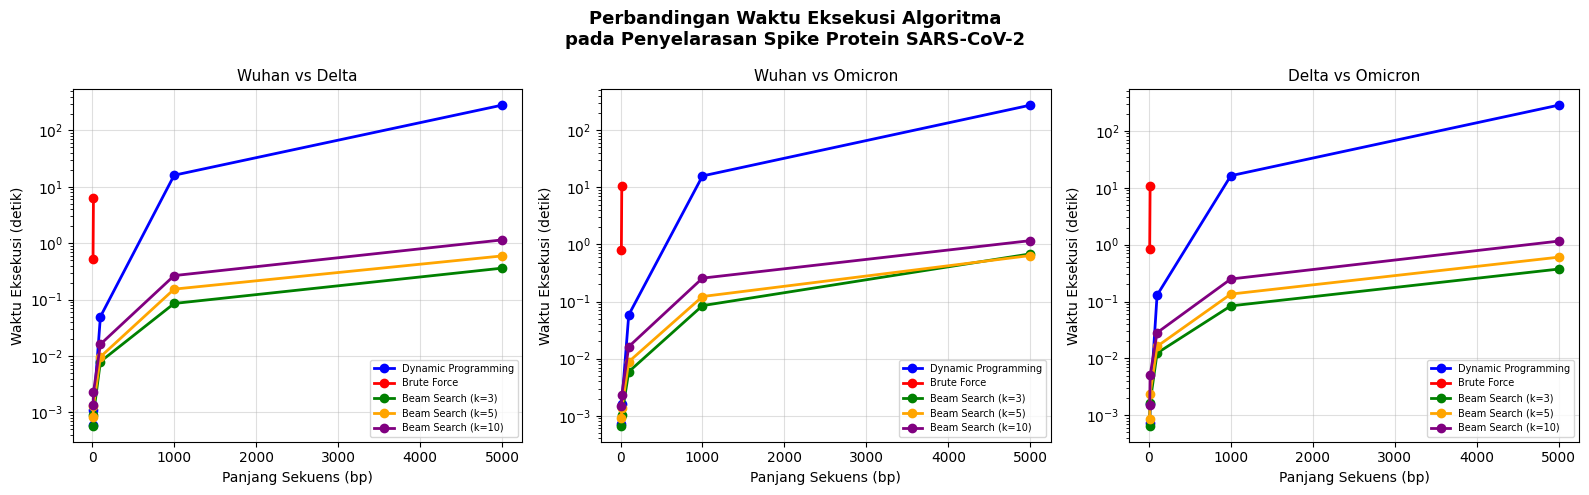

grafik disimpan ke results/grafik_runtime.png


In [12]:
# 11. Grafik Perbandingan Waktu Eksekusi

df_ok = df_hasil[df_hasil["Keterangan"] == "OK"].copy()
df_ok["Waktu (detik)"] = pd.to_numeric(df_ok["Waktu (detik)"])
warna = {
    "Dynamic Programming" : "blue",
    "Brute Force"         : "red",
    "Beam Search (k=3)"   : "green",
    "Beam Search (k=5)"   : "orange",
    "Beam Search (k=10)"  : "purple",
}
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Perbandingan Waktu Eksekusi Algoritma\npada Penyelarasan Spike Protein SARS-CoV-2",
             fontsize=13, fontweight="bold")
for ax, nama_pasangan in zip(axes, pasangan.keys()):
    df_pair = df_ok[df_ok["Pasangan"] == nama_pasangan]
    for nama_algo in [x[0] for x in algoritma_list]:
        df_algo = df_pair[df_pair["Algoritma"] == nama_algo]
        if df_algo.empty:
            continue
        ax.plot(df_algo["Panjang (bp)"], df_algo["Waktu (detik)"],
                marker="o", label=nama_algo,
                color=warna.get(nama_algo, "gray"), linewidth=2)
    ax.set_title(nama_pasangan, fontsize=11)
    ax.set_xlabel("Panjang Sekuens (bp)")
    ax.set_ylabel("Waktu Eksekusi (detik)")
    ax.set_yscale("log")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("results/grafik_runtime.png", dpi=150, bbox_inches="tight")
plt.show()
print("grafik disimpan ke results/grafik_runtime.png")

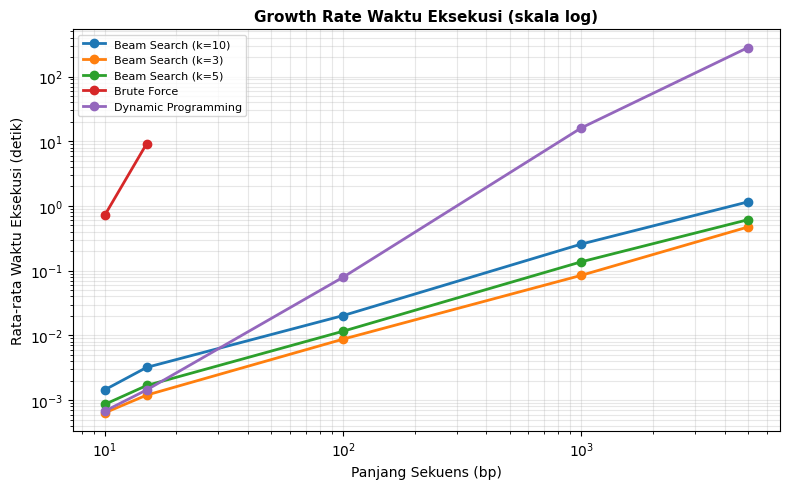

grafik disimpan ke results/grafik_growth_rate.png


In [13]:
# 11b. Growth Rate Waktu Eksekusi

import numpy as np

df_growth = df_hasil[df_hasil["Keterangan"] == "OK"].copy()
df_growth["Waktu (detik)"] = pd.to_numeric(df_growth["Waktu (detik)"])
df_avg = df_growth.groupby(["Algoritma", "Panjang (bp)"])["Waktu (detik)"].mean().reset_index()

plt.figure(figsize=(8, 5))
for nama_algo in df_avg["Algoritma"].unique():
    df_a = df_avg[df_avg["Algoritma"] == nama_algo].sort_values("Panjang (bp)")
    if len(df_a) < 2:
        continue
    plt.plot(df_a["Panjang (bp)"], df_a["Waktu (detik)"],
             marker="o", label=nama_algo, linewidth=2)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Panjang Sekuens (bp)")
plt.ylabel("Rata-rata Waktu Eksekusi (detik)")
plt.title("Growth Rate Waktu Eksekusi (skala log)",
          fontsize=11, fontweight="bold")
plt.legend(fontsize=8)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("results/grafik_growth_rate.png", dpi=150, bbox_inches="tight")
plt.show()
print("grafik disimpan ke results/grafik_growth_rate.png")

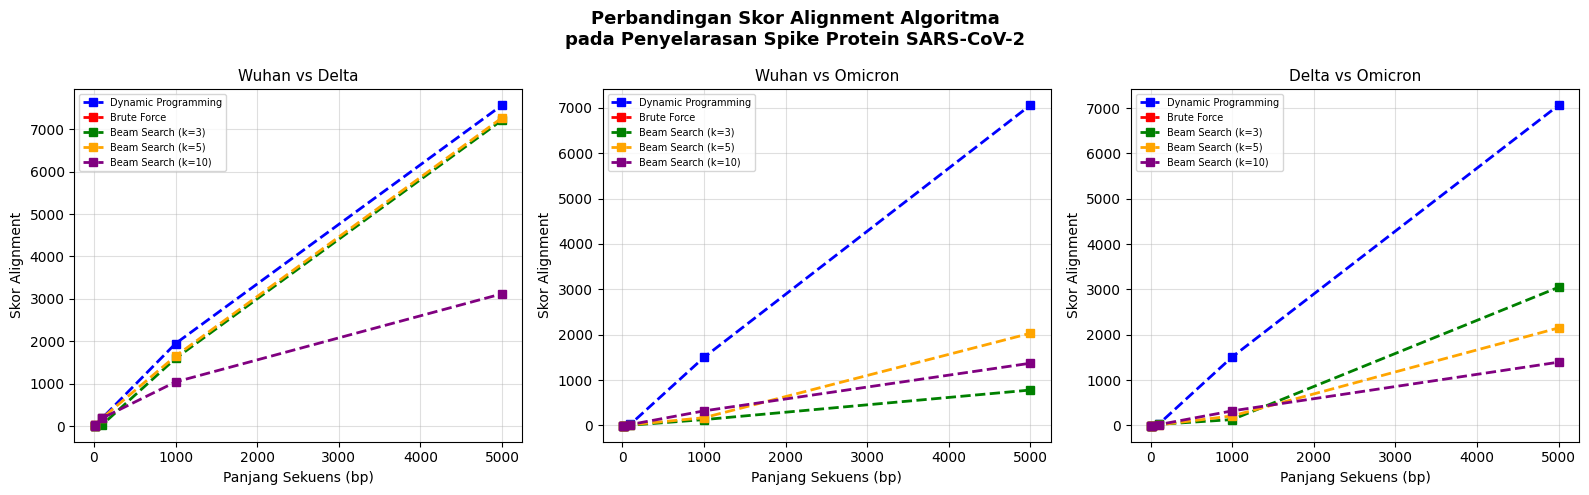

grafik disimpan ke results/grafik_skor.png


In [14]:
# 12. Grafik Perbandingan Skor

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Perbandingan Skor Alignment Algoritma\npada Penyelarasan Spike Protein SARS-CoV-2",
             fontsize=13, fontweight="bold")
for ax, nama_pasangan in zip(axes, pasangan.keys()):
    df_pair = df_ok[df_ok["Pasangan"] == nama_pasangan]
    for nama_algo in [x[0] for x in algoritma_list]:
        df_algo = df_pair[df_pair["Algoritma"] == nama_algo]
        if df_algo.empty:
            continue
        ax.plot(df_algo["Panjang (bp)"], df_algo["Skor"],
                marker="s", label=nama_algo, linestyle="--",
                color=warna.get(nama_algo, "gray"), linewidth=2)
    ax.set_title(nama_pasangan, fontsize=11)
    ax.set_xlabel("Panjang Sekuens (bp)")
    ax.set_ylabel("Skor Alignment")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("results/grafik_skor.png", dpi=150, bbox_inches="tight")
plt.show()
print("grafik disimpan ke results/grafik_skor.png")

In [15]:
# 12b. Tabel Akurasi Relatif Beam Search terhadap DP

print("selisih skor Beam Search terhadap DP")
print("(negatif = beam search lebih rendah dari DP)")
print()
df_ok_num = df_hasil[df_hasil["Keterangan"] == "OK"].copy()
df_ok_num["Skor"] = pd.to_numeric(df_ok_num["Skor"])
for nama_pasangan in pasangan.keys():
    df_pair = df_ok_num[df_ok_num["Pasangan"] == nama_pasangan]
    df_dp   = df_pair[df_pair["Algoritma"] == "Dynamic Programming"][["Panjang (bp)", "Skor"]]
    df_dp   = df_dp.rename(columns={"Skor": "Skor_DP"})
    baris_list = []
    for nama_algo in ["Beam Search (k=3)", "Beam Search (k=5)", "Beam Search (k=10)"]:
        df_bs = df_pair[df_pair["Algoritma"] == nama_algo][["Panjang (bp)", "Skor"]]
        df_bs = df_bs.rename(columns={"Skor": "Skor_BS"})
        df_merge = pd.merge(df_dp, df_bs, on="Panjang (bp)")
        df_merge["Selisih"]     = df_merge["Skor_BS"] - df_merge["Skor_DP"]
        df_merge["Selisih (%)"] = (df_merge["Selisih"] / df_merge["Skor_DP"].abs() * 100).round(2)
        df_merge["Algoritma"]   = nama_algo
        baris_list.append(df_merge)
    if baris_list:
        df_akurasi = pd.concat(baris_list)
        df_akurasi = df_akurasi[["Algoritma", "Panjang (bp)", "Skor_DP", "Skor_BS", "Selisih", "Selisih (%)"]]
        df_akurasi = df_akurasi.sort_values(["Algoritma", "Panjang (bp)"]).reset_index(drop=True)
        print(f"Pasangan: {nama_pasangan}")
        display(df_akurasi)
        print()

selisih skor Beam Search terhadap DP
(negatif = beam search lebih rendah dari DP)

Pasangan: Wuhan vs Delta


,Algoritma,Panjang (bp),Skor_DP,Skor_BS,Selisih,Selisih (%)
0,Beam Search (k=10),10,8,8,0,0.00
1,Beam Search (k=10),15,18,18,0,0.00
2,Beam Search (k=10),100,185,185,0,0.00
3,Beam Search (k=10),1000,1946,1040,-906,-46.56
4,Beam Search (k=10),5000,7569,3120,-4449,-58.78
5,Beam Search (k=3),10,8,8,0,0.00
6,Beam Search (k=3),15,18,9,-9,-50.00
7,Beam Search (k=3),100,185,29,-156,-84.32
8,Beam Search (k=3),1000,1946,1595,-351,-18.04
9,Beam Search (k=3),5000,7569,7218,-351,-4.64



Pasangan: Wuhan vs Omicron


,Algoritma,Panjang (bp),Skor_DP,Skor_BS,Selisih,Selisih (%)
0,Beam Search (k=10),10,-4,-4,0,0.00
1,Beam Search (k=10),15,-6,-6,0,0.00
2,Beam Search (k=10),100,26,20,-6,-23.08
3,Beam Search (k=10),1000,1499,320,-1179,-78.65
4,Beam Search (k=10),5000,7059,1371,-5688,-80.58
5,Beam Search (k=3),10,-4,-4,0,0.00
6,Beam Search (k=3),15,-6,-6,0,0.00
7,Beam Search (k=3),100,26,5,-21,-80.77
8,Beam Search (k=3),1000,1499,128,-1371,-91.46
9,Beam Search (k=3),5000,7059,780,-6279,-88.95



Pasangan: Delta vs Omicron


,Algoritma,Panjang (bp),Skor_DP,Skor_BS,Selisih,Selisih (%)
0,Beam Search (k=10),10,-7,-7,0,0.00
1,Beam Search (k=10),15,-3,-3,0,0.00
2,Beam Search (k=10),100,29,17,-12,-41.38
3,Beam Search (k=10),1000,1511,320,-1191,-78.82
4,Beam Search (k=10),5000,7065,1395,-5670,-80.25
5,Beam Search (k=3),10,-7,-7,0,0.00
6,Beam Search (k=3),15,-3,-3,0,0.00
7,Beam Search (k=3),100,29,23,-6,-20.69
8,Beam Search (k=3),1000,1511,128,-1383,-91.53
9,Beam Search (k=3),5000,7065,3048,-4017,-56.86



Pasangan: Wuhan vs Delta  (200 bp pertama)
----------------------------------------

  algoritma             total    sub    ins    del
  ---------------------------------------------
  Dynamic Programming       5      1      2      2
  Beam Search (k=10)        5      1      2      2

  posisi mutasi yang sama    : 5
  hanya terdeteksi DP        : 0
  hanya terdeteksi BS k=10   : 0

  alignment: Wuhan vs Delta
  (| = sama, X = beda, spasi = gap)

  Wuhan     : ATGTTTGTTTTTCTTGTTTTATTGCCACTAGTCTCTAGTCAGTGTGTTAATCTTACAACC
                |||||||||||||||||||||||||||||||||||||||||||||||||||||X||||
  Delta     : --GTTTGTTTTTCTTGTTTTATTGCCACTAGTCTCTAGTCAGTGTGTTAATCTTAGAACC

  Wuhan     : AGAACTCAATTACCCCCTGCATACACTAATTCTTTCACACGTGGTGTTTATTACCCTGAC
              ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
  Delta     : AGAACTCAATTACCCCCTGCATACACTAATTCTTTCACACGTGGTGTTTATTACCCTGAC


Pasangan: Wuhan vs Omicron  (200 bp pertama)
----------------------------------------

  algor

,Pasangan,Mutasi DP,Mutasi BS k=10,Posisi Sama,Hanya DP,Hanya BS
0,Wuhan vs Delta,5,5,5,0,0
1,Wuhan vs Omicron,110,114,55,55,59
2,Delta vs Omicron,108,110,58,50,52


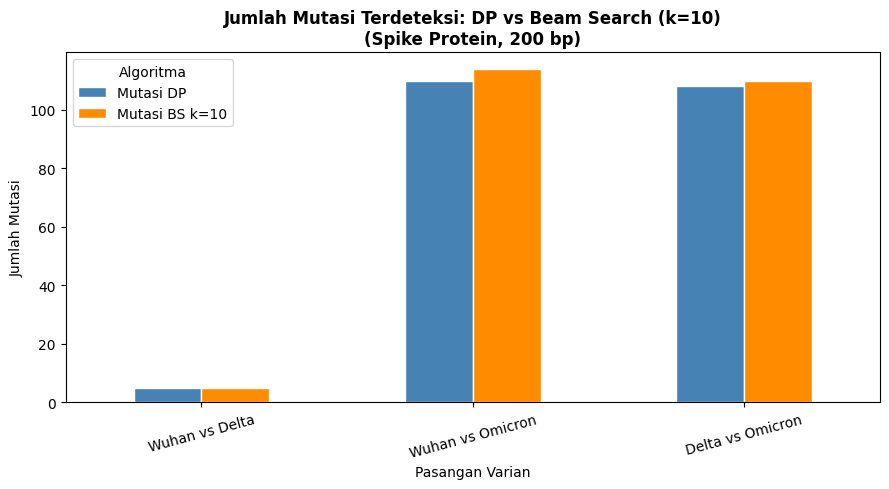

grafik disimpan ke results/grafik_mutasi.png


In [16]:
# 13. Deteksi Mutasi: DP vs Beam Search

PANJANG_DEMO = 200

def deteksi_mutasi(al1, al2, nama1, nama2):
    daftar = []
    for posisi, (a, b) in enumerate(zip(al1, al2), start=1):
        if a == b:
            continue
        if a == "-":
            jenis = "Insersi"
        elif b == "-":
            jenis = "Delesi"
        else:
            jenis = "Substitusi"
        daftar.append({
            "Posisi" : posisi,
            "Jenis"  : jenis,
            nama1    : a,
            nama2    : b
        })
    return daftar

def tampilkan_alignment(al1, al2, nama1, nama2, panjang_tampil=120):
    print(f"  alignment: {nama1} vs {nama2}")
    print(f"  (| = sama, X = beda, spasi = gap)")
    print()
    for mulai in range(0, min(len(al1), panjang_tampil), 60):
        p1  = al1[mulai:mulai+60]
        p2  = al2[mulai:mulai+60]
        mid = ""
        for a, b in zip(p1, p2):
            if a == b:
                mid += "|"
            elif a == "-" or b == "-":
                mid += " "
            else:
                mid += "X"
        print(f"  {nama1:<10}: {p1}")
        print(f"  {'':10}  {mid}")
        print(f"  {nama2:<10}: {p2}")
        print()

ringkasan_mutasi = []
for nama_pasangan, (s1, s2) in pasangan.items():
    nama1, nama2 = nama_pasangan.split(" vs ")
    print()
    print(f"Pasangan: {nama_pasangan}  ({PANJANG_DEMO} bp pertama)")
    print("-" * 40)

    # alignment pakai DP dulu
    _, al_dp1, al_dp2 = needleman_wunsch(s1[:PANJANG_DEMO], s2[:PANJANG_DEMO])
    mutasi_dp          = deteksi_mutasi(al_dp1, al_dp2, nama1, nama2)
    posisi_dp          = set(m["Posisi"] for m in mutasi_dp)

    # bandingkan dengan beam search k=10
    _, al_bs1, al_bs2 = beam_search(s1[:PANJANG_DEMO], s2[:PANJANG_DEMO], beam_width=10)
    mutasi_bs          = deteksi_mutasi(al_bs1, al_bs2, nama1, nama2)
    posisi_bs          = set(m["Posisi"] for m in mutasi_bs)

    posisi_sama     = posisi_dp & posisi_bs
    posisi_hanya_dp = posisi_dp - posisi_bs
    posisi_hanya_bs = posisi_bs - posisi_dp

    print()
    print(f"  {'algoritma':<20} {'total':>6}  {'sub':>5}  {'ins':>5}  {'del':>5}")
    print("  " + "-" * 45)
    print(f"  {'Dynamic Programming':<20} "
          f"{len(mutasi_dp):>6}  "
          f"{sum(1 for m in mutasi_dp if m['Jenis']=='Substitusi'):>5}  "
          f"{sum(1 for m in mutasi_dp if m['Jenis']=='Insersi'):>5}  "
          f"{sum(1 for m in mutasi_dp if m['Jenis']=='Delesi'):>5}")
    print(f"  {'Beam Search (k=10)':<20} "
          f"{len(mutasi_bs):>6}  "
          f"{sum(1 for m in mutasi_bs if m['Jenis']=='Substitusi'):>5}  "
          f"{sum(1 for m in mutasi_bs if m['Jenis']=='Insersi'):>5}  "
          f"{sum(1 for m in mutasi_bs if m['Jenis']=='Delesi'):>5}")
    print()
    print(f"  posisi mutasi yang sama    : {len(posisi_sama)}")
    print(f"  hanya terdeteksi DP        : {len(posisi_hanya_dp)}")
    print(f"  hanya terdeteksi BS k=10   : {len(posisi_hanya_bs)}")
    print()
    tampilkan_alignment(al_dp1, al_dp2, nama1, nama2)
    ringkasan_mutasi.append({
        "Pasangan"       : nama_pasangan,
        "Mutasi DP"      : len(mutasi_dp),
        "Mutasi BS k=10" : len(mutasi_bs),
        "Posisi Sama"    : len(posisi_sama),
        "Hanya DP"       : len(posisi_hanya_dp),
        "Hanya BS"       : len(posisi_hanya_bs),
    })

df_ring = pd.DataFrame(ringkasan_mutasi)
print()
print("ringkasan deteksi mutasi: DP vs Beam Search (k=10)")
print("-" * 40)
display(df_ring)
df_ring.set_index("Pasangan")[["Mutasi DP", "Mutasi BS k=10"]].plot(
    kind="bar", figsize=(9, 5),
    color=["steelblue", "darkorange"], edgecolor="white"
)
plt.title(f"Jumlah Mutasi Terdeteksi: DP vs Beam Search (k=10)\n"
          f"(Spike Protein, {PANJANG_DEMO} bp)", fontsize=12, fontweight="bold")
plt.xlabel("Pasangan Varian")
plt.ylabel("Jumlah Mutasi")
plt.xticks(rotation=15)
plt.legend(title="Algoritma")
plt.tight_layout()
plt.savefig("results/grafik_mutasi.png", dpi=150, bbox_inches="tight")
plt.show()
print("grafik disimpan ke results/grafik_mutasi.png")

In [17]:
# 14. Simpan Hasil ke CSV

# Simpan semua hasil ke file CSV

df_hasil.to_csv("results/hasil_eksperimen.csv", index=False, encoding="utf-8-sig")
print("Tersimpan: results/hasil_eksperimen.csv")
df_ring.to_csv("results/ringkasan_mutasi.csv", index=False, encoding="utf-8-sig")
print("Tersimpan: results/ringkasan_mutasi.csv")

# Tampilkan ringkasan akhir
print()
print("RINGKASAN AKHIR EKSPERIMEN")
display(df_ring)

print("\nFile yang dihasilkan di folder results/:")
for nama_file in os.listdir("results"):
    ukuran = os.path.getsize(f"results/{nama_file}")
    print(f"  {nama_file}  ({ukuran} bytes)")

Tersimpan: results/hasil_eksperimen.csv
Tersimpan: results/ringkasan_mutasi.csv

RINGKASAN AKHIR EKSPERIMEN


,Pasangan,Mutasi DP,Mutasi BS k=10,Posisi Sama,Hanya DP,Hanya BS
0,Wuhan vs Delta,5,5,5,0,0
1,Wuhan vs Omicron,110,114,55,55,59
2,Delta vs Omicron,108,110,58,50,52



File yang dihasilkan di folder results/:
  hasil_eksperimen.csv  (4640 bytes)
  grafik_mutasi.png  (63121 bytes)
  ringkasan_mutasi.csv  (160 bytes)
  heatmap_matriks_dp.png  (255451 bytes)
  grafik_runtime.png  (161512 bytes)
  grafik_skor.png  (175077 bytes)
  grafik_growth_rate.png  (114420 bytes)


## **Kesimpulan**

1. Dynamic Programming (Needleman-Wunsch)<br>
Menghasilkan skor alignment tertinggi di semua pasangan dan semua panjang sekuens. Pada sekuens 5000 bp, DP menghasilkan skor 7569 (Wuhan vs Delta), 7059 (Wuhan vs Omicron), dan 7065 (Delta vs Omicron). Waktu eksekusinya sangat tinggi, mencapai 275 hingga 283 detik di panjang 5000 bp, konsisten dengan kompleksitas O(m x n). Algoritma ini cocok digunakan ketika akurasi menjadi prioritas utama dan ukuran sekuens tidak terlalu besar.</p>
2. Brute Force<br>
Hanya bisa dijalankan pada sekuens ≤ 15 bp karena jumlah kombinasi yang dievaluasi tumbuh secara eksponensial. Pada 15 bp saja waktu eksekusinya sudah mencapai 6 hingga 11 detik. Meski begitu, pada panjang 10 dan 15 bp skornya identik dengan DP, yaitu 18 pada Wuhan vs Delta, -6 pada Wuhan vs Omicron, dan -3 pada Delta vs Omicron, yang membuktikan bahwa Brute Force memang menemukan solusi optimal. Keterbatasan ini menjadikannya tidak praktis untuk analisis genom skala nyata.</p>
3. Beam Search<br>
Jauh lebih cepat dibanding DP. Di panjang 5000 bp, Beam Search (k=5) hanya membutuhkan sekitar 0.60 hingga 0.64 detik dibanding DP yang memerlukan lebih dari 4 menit. Namun akurasinya menurun signifikan pada sekuens panjang, dengan selisih skor terhadap DP mencapai 71.23% hingga 88.66% pada pasangan Wuhan vs Omicron dan 56.86% hingga 86.17% pada Delta vs Omicron. Pada Wuhan vs Delta, Beam Search masih mampu menghasilkan skor yang relatif mendekati DP dengan selisih hanya sekitar 3.92% pada k=5 di panjang 5000 bp. Menariknya, Beam Search (k=10) tidak selalu lebih baik dari k=5, bahkan di beberapa kasus menghasilkan skor lebih rendah. Hal ini terjadi karena deduplication berdasarkan posisi (i,j) menyebabkan kandidat dengan skor tinggi bisa tergantikan oleh kandidat lain yang mencapai posisi yang sama lebih dulu, sehingga menambah beam_width tidak selalu menjamin hasil yang lebih optimal.</p>
4. Deteksi Mutasi<br>
Pada pasangan Wuhan vs Delta yang sekuensnya relatif mirip, DP dan Beam Search (k=10) mendeteksi posisi mutasi yang persis sama yaitu 5 mutasi. Namun pada Wuhan vs Omicron yang perbedaannya lebih besar, DP mendeteksi 110 mutasi sementara Beam Search (k=10) mendeteksi 114 mutasi dengan hanya 55 posisi yang sama di antara keduanya. Pada Delta vs Omicron, DP mendeteksi 108 mutasi sedangkan Beam Search mendeteksi 110 mutasi dengan 58 posisi yang sama. Perbedaan ini muncul karena pruning kandidat pada Beam Search menghasilkan jalur alignment yang berbeda, sehingga posisi mutasi yang terdeteksi pun tidak selalu konsisten dengan hasil DP.</p>